In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\vishw\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [2]:
import shutil
import os

for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), os.getcwd())

print(os.listdir(os.getcwd()))

['creditcard.csv', 'notebook.ipynb', 'venv']


In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("creditcard.csv")

In [4]:
# exploring the dataset
print(data.shape)
print(data.head())
print(data.info())
print(data.isnull().sum())
print(data['Class'].value_counts())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [5]:
# checking for missing values, duplicates and data types
print(data.isnull().sum().sum())   # any missing values?
print(data.duplicated().sum())     # any duplicate rows?
print(data.dtypes.value_counts())  # data types overview


0
1081
float64    30
int64       1
Name: count, dtype: int64


In [6]:
# dropping the duplicate data 
data = data.drop_duplicates()
print(data.shape)
print(data['Class'].value_counts())

(283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64


In [7]:
# checking the correlation of features with the target variable
corr = data.corr()['Class'].sort_values(ascending=False)
print(corr)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


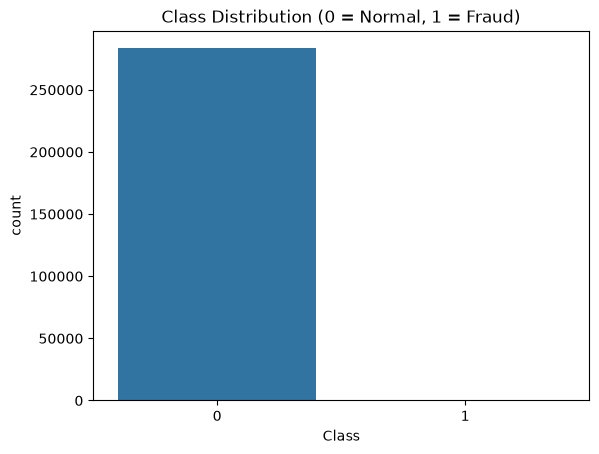

In [8]:
# visualizing the class distribution

sns.countplot(x='Class', data=data)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.show()

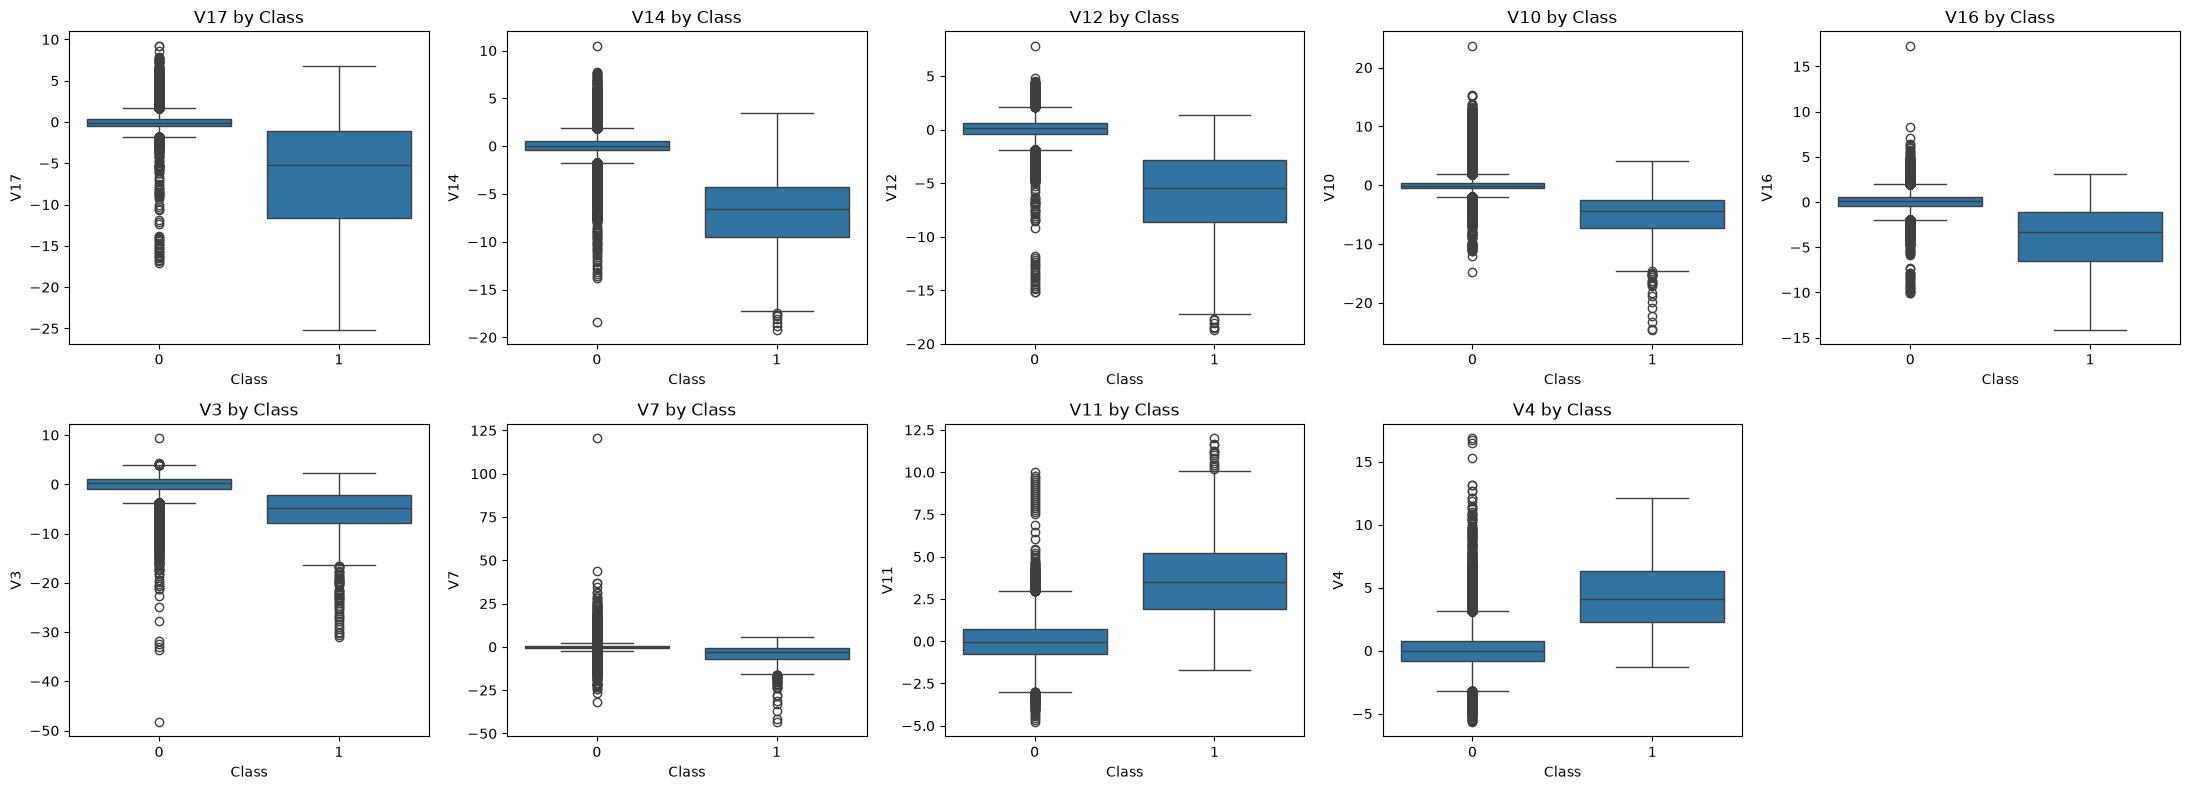

In [9]:
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4']

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(x='Class', y=col, data=data, ax=axes[i])
    axes[i].set_title(f'{col} by Class')

# hide the unused subplot (9 features, 10 slots)
axes[-1].axis('off')

plt.tight_layout()
plt.show()


In [10]:
# preprocessing 
X = data.drop(columns=['Class'])
y = data['Class']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

**Conclusion:** Train and test sets maintain the same ~0.17% fraud ratio (378/226,980 in train, 95/56,746 in test), confirming stratified sampling worked correctly.

## Model Building
We'll train and compare three approaches to handle the class imbalance:
1. Logistic Regression with class weighting
2. XGBoost with `scale_pos_weight`
3. XGBoost with SMOTE oversampling

Each model will be evaluated using confusion matrix, precision, recall, F1-score, ROC-AUC, and PR-AUC — not accuracy, since it's misleading on imbalanced data.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

precision, recall, _ = precision_recall_curve(y_test, y_proba_lr)
print("PR-AUC:", auc(recall, precision))

Confusion Matrix:
[[55258  1393]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC-AUC: 0.9658392242808925
PR-AUC: 0.7046360387811649


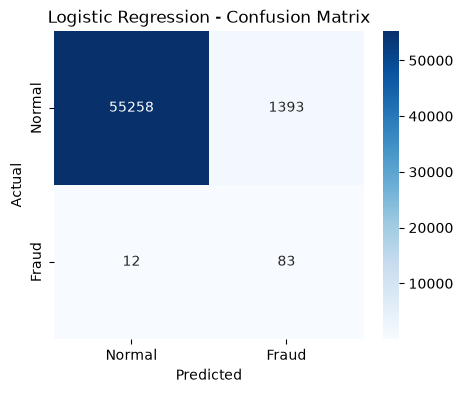

In [14]:


cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

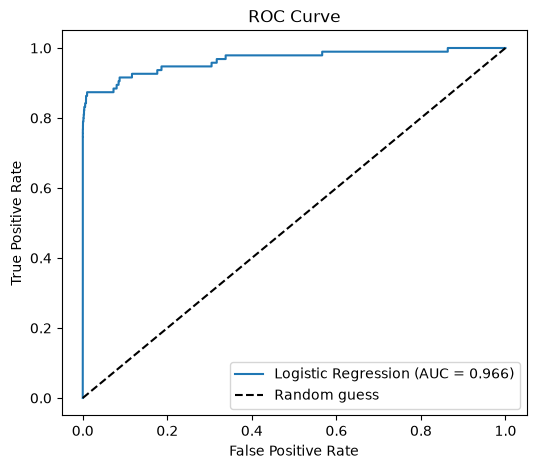

In [15]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

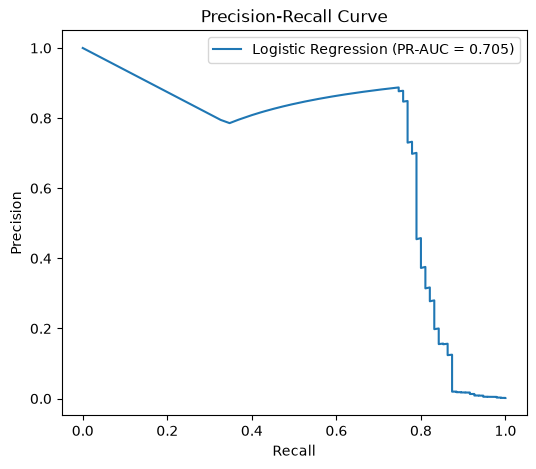

In [16]:
precision, recall, _ = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'Logistic Regression (PR-AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

### Visualizing Logistic Regression Performance

The confusion matrix shows the model catches most fraud cases (83/95) but generates a large number of false positives (1,388) on normal transactions.

The ROC curve (AUC = 0.966) looks very strong, but this is partly misleading due to class imbalance — a large number of false positives barely affects the false positive *rate* when the normal class is so large.

The Precision-Recall curve gives a more honest picture: precision drops sharply once recall exceeds ~0.7, confirming that pushing the model to catch more fraud comes at a steep cost in false alarms. This is the central tradeoff we'll need to manage, and a key benchmark (PR-AUC = 0.707) for comparing against XGBoost next.

## XGBoost Model

XGBoost is a gradient boosting algorithm well-suited for imbalanced, tabular classification problems. Instead of resampling the data, we use its built-in `scale_pos_weight` parameter to tell the model how much more to penalize misclassifying the minority (fraud) class, calculated as the ratio of normal to fraud transactions in the training set.

In [17]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
print("PR-AUC:", auc(recall, precision))

scale_pos_weight: 599.4761904761905
Confusion Matrix:
[[56648     3]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.77      0.85        95

    accuracy                           1.00     56746
   macro avg       0.98      0.88      0.93     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9790064559644509
PR-AUC: 0.823415809344725


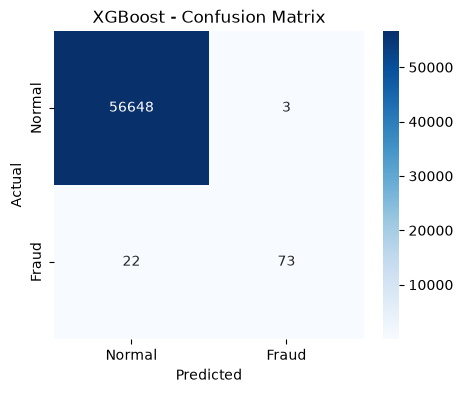

In [18]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost - Confusion Matrix')
plt.show()

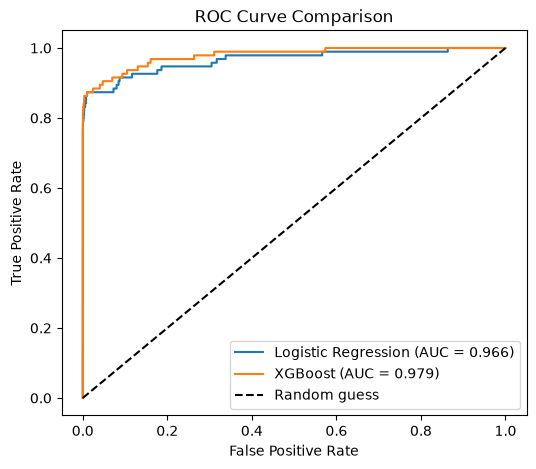

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

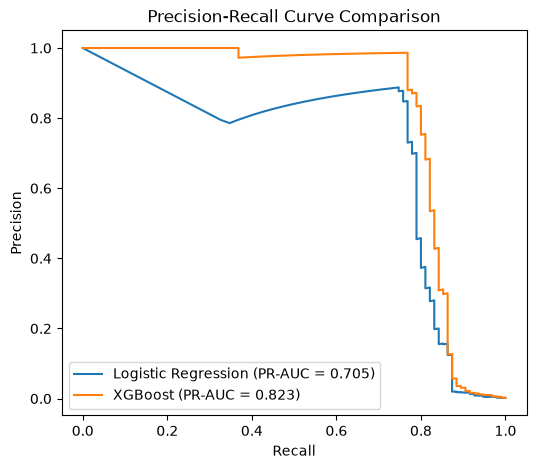

In [20]:
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)

pr_auc_lr = auc(recall_lr, precision_lr)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

plt.figure(figsize=(6,5))
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.3f})')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

### Model Comparison — ROC and Precision-Recall Curves

The ROC curves for both models look similar (AUC 0.966 vs 0.979), which illustrates a known limitation of ROC-AUC on imbalanced datasets — it can understate real differences in model quality since the false positive *rate* is diluted by the very large normal class.

The Precision-Recall curve tells a clearer story: XGBoost maintains near-perfect precision up to ~75% recall, while Logistic Regression's precision degrades much earlier. XGBoost consistently outperforms Logistic Regression across almost the entire recall range, confirmed by its higher PR-AUC (0.823 vs 0.707). This supports our earlier conclusion that XGBoost is the stronger model for this problem, offering far fewer false positives for a comparable ability to catch fraud.

## XGBoost + SMOTE

As a third comparison, we apply SMOTE (Synthetic Minority Oversampling Technique) to the training data only, generating synthetic fraud examples to balance the classes before training XGBoost. This lets us directly compare "algorithm-level" imbalance handling (scale_pos_weight) against "data-level" imbalance handling (SMOTE) on the same model.

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 226602}


**Conclusion:** SMOTE successfully balanced the training set from 378 fraud cases to 226,602 (matching the normal class), by generating synthetic fraud examples through interpolation. The test set remains untouched at its original imbalanced ratio, ensuring evaluation reflects real-world conditions.

In [22]:
xgb_smote = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_smote))

precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb_smote)
print("PR-AUC:", auc(recall, precision))

Confusion Matrix:
[[56623    28]
 [   19    76]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.80      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.90      0.88     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9662283101798732
PR-AUC: 0.8140118793499228


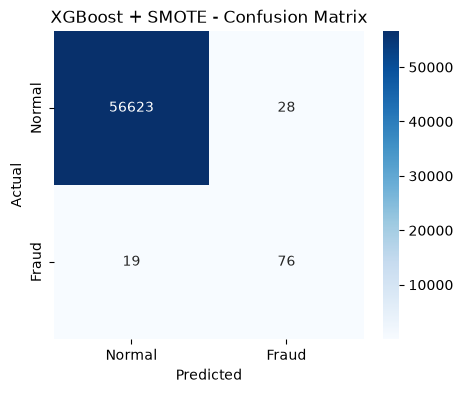

In [24]:
cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost + SMOTE - Confusion Matrix')
plt.show()

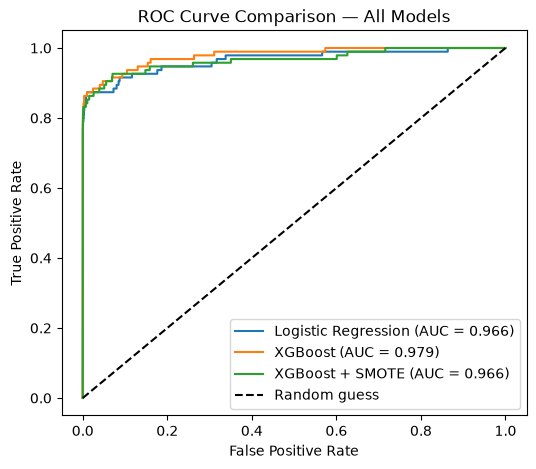

In [25]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_xgb_smote, tpr_xgb_smote, _ = roc_curve(y_test, y_proba_xgb_smote)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})')
plt.plot(fpr_xgb_smote, tpr_xgb_smote, label=f'XGBoost + SMOTE (AUC = {roc_auc_score(y_test, y_proba_xgb_smote):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.show()

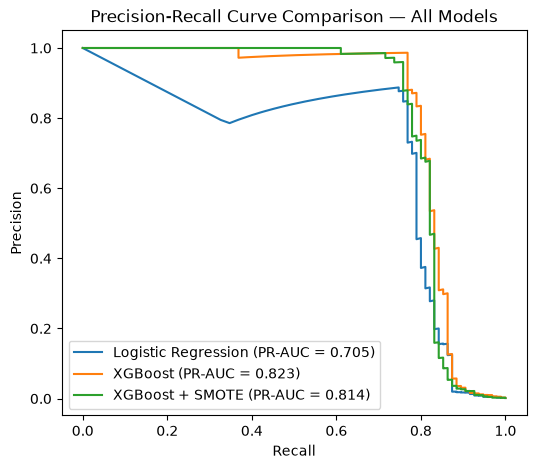

In [26]:
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
precision_xgb_smote, recall_xgb_smote, _ = precision_recall_curve(y_test, y_proba_xgb_smote)

plt.figure(figsize=(6,5))
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (PR-AUC = {auc(recall_lr, precision_lr):.3f})')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {auc(recall_xgb, precision_xgb):.3f})')
plt.plot(recall_xgb_smote, precision_xgb_smote, label=f'XGBoost + SMOTE (PR-AUC = {auc(recall_xgb_smote, precision_xgb_smote):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison — All Models')
plt.legend()
plt.show()

### Final Model Comparison — Visual Summary

The Precision-Recall curve comparison is the clearest evidence for model selection given the severe class imbalance. Logistic Regression consistently underperforms both XGBoost variants. Plain XGBoost (scale_pos_weight) and XGBoost + SMOTE perform very similarly, with plain XGBoost holding a slight edge in the 0.75–0.85 recall range, consistent with its higher PR-AUC (0.823 vs 0.814).

The ROC curves for all three models look deceptively similar, reinforcing that ROC-AUC is not a reliable metric for distinguishing model quality on highly imbalanced datasets like this one.

**Final decision: XGBoost with `scale_pos_weight` is selected as the production model**, based on its superior precision, F1-score, and PR-AUC, while maintaining strong recall.

## Saving the Final Model

We save the selected XGBoost model along with the StandardScaler (used for `Time` and `Amount`) so they can be loaded directly by the web application without needing to retrain.

In [27]:
import joblib

joblib.dump(xgb, 'fraud_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [28]:
loaded_model = joblib.load('fraud_detection_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# quick test: predict on the first 5 rows of X_test
sample_preds = loaded_model.predict(X_test.iloc[:5])
print("Sample predictions:", sample_preds)
print("Actual labels:", y_test.iloc[:5].values)

Sample predictions: [0 0 0 0 0]
Actual labels: [0 0 0 0 0]


In [30]:
# median defaults from training data (unscaled, original values)
X_unscaled = data.drop(columns=['Class'])  # original data before split/scaling
feature_defaults = X_unscaled.median()

print(feature_defaults)

# save defaults + column order + selected feature list
import joblib

selected_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'Amount']

joblib.dump(feature_defaults, 'feature_defaults.pkl')
joblib.dump(list(X_train.columns), 'feature_columns.pkl')
joblib.dump(selected_features, 'selected_features.pkl')

print("Defaults and feature metadata saved.")

Time      84692.500000
V1            0.020384
V2            0.063949
V3            0.179963
V4           -0.022248
V5           -0.053468
V6           -0.275168
V7            0.040859
V8            0.021898
V9           -0.052596
V10          -0.093237
V11          -0.032306
V12           0.139072
V13          -0.012927
V14           0.050209
V15           0.049299
V16           0.067119
V17          -0.065867
V18          -0.002142
V19           0.003367
V20          -0.062353
V21          -0.029441
V22           0.006675
V23          -0.011159
V24           0.041016
V25           0.016278
V26          -0.052172
V27           0.001479
V28           0.011288
Amount       22.000000
dtype: float64
Defaults and feature metadata saved.


In [35]:
user_input_ambiguous = {
    'V17': -3.0,   # moderately negative, not extreme
    'V14': -2.5,
    'V12': -1.5,
    'V10': -1.0,
    'V16': -1.0,
    'V3': -1.5,
    'V7': -0.5,
    'V11': 1.5,
    'V4': 1.2,
    'Amount': 500.00
}

full_input = feature_defaults.copy()
for key, value in user_input_ambiguous.items():
    full_input[key] = value

full_input_df = pd.DataFrame([full_input])[X_train.columns]
full_input_df[['Time', 'Amount']] = scaler.transform(full_input_df[['Time', 'Amount']])

prediction = xgb.predict(full_input_df)[0]
probability = xgb.predict_proba(full_input_df)[0][1]

print("Prediction:", "Fraud" if prediction == 1 else "Normal")
print("Fraud Probability:", round(probability, 4))

Prediction: Normal
Fraud Probability: 0.0596


In [36]:
sample = data.drop(columns=['Class']).sample(10, random_state=1)
sample.to_csv('sample_transactions.csv', index=False)
print("Saved sample_transactions.csv")

Saved sample_transactions.csv


In [37]:
import numpy as np
import pandas as pd

# reference points: median of fraud cases vs median of normal cases
fraud_median = data[data['Class'] == 1].drop(columns=['Class']).median()
normal_median = data[data['Class'] == 0].drop(columns=['Class']).median()

candidates = []

# interpolate between "normal" and "fraud" profiles at different mixing ratios
for alpha in np.linspace(0.05, 0.95, 40):  # 0 = fully normal, 1 = fully fraud
    row = normal_median * (1 - alpha) + fraud_median * alpha
    candidates.append(row)

candidates_df = pd.DataFrame(candidates)
candidates_df = candidates_df[X_train.columns]  # correct column order

# scale Time and Amount using the saved scaler
scaled_df = candidates_df.copy()
scaled_df[['Time', 'Amount']] = scaler.transform(scaled_df[['Time', 'Amount']])

# get predicted probabilities using the actual trained model
probs = xgb.predict_proba(scaled_df)[:, 1]
candidates_df['Fraud_Probability'] = probs

# keep only genuinely ambiguous ones (not near 0 or 1)
ambiguous_df = candidates_df[(candidates_df['Fraud_Probability'] > 0.2) & (candidates_df['Fraud_Probability'] < 0.8)]

print(f"Found {len(ambiguous_df)} ambiguous rows out of 40 tried")
print(ambiguous_df['Fraud_Probability'].values)

# save without the probability column (so it matches the format your app expects)
ambiguous_df.drop(columns=['Fraud_Probability']).to_csv('ambiguous_transactions.csv', index=False)
print("Saved ambiguous_transactions.csv")

Found 5 ambiguous rows out of 40 tried
[0.58839256 0.53751415 0.5935357  0.40742767 0.7263523 ]
Saved ambiguous_transactions.csv
